## Phase 5 - Classical Model Development and Evaluation

This section develops and evaluates classical machine learning models for drug–drug interaction classification. A range of approaches, including rule-based methods, Naive Bayes, Logistic Regression, Random Forest, and Linear SVM, are implemented using TF-IDF and handcrafted features.

Models are assessed using Macro F1 as the primary metric due to class imbalance, along with additional metrics and detailed error analysis to understand performance across interaction types.

## Baseline Model Environment and Evaluation Setup

This section initialises the environment for baseline model development and evaluation by importing the required libraries and loading project configuration settings. Centralising the configuration ensures consistent use of predefined paths, parameters, and experimental settings across all stages of the pipeline.

Standard libraries are included for data handling, numerical computation, and file operations, while machine learning utilities from *scikit-learn* support model training, cross-validation, and performance evaluation. In addition, libraries for visualisation are configured to enable consistent and interpretable plotting of results.

Dedicated directories for storing figures and evaluation metrics are created to ensure organised output management. Global plotting parameters are defined to maintain a uniform visual style across all generated figures, improving readability and presentation quality.

Finally, colour mappings for class labels and models are specified to ensure consistency across evaluation visualisations, facilitating clear comparison of model performance in subsequent analyses.

In [1]:
# Path Setup: Import Project Configuration
import sys, os
sys.path.insert(0, os.path.abspath('../'))
from config import *


# Standard Library Imports
import os
import pickle
import warnings
from pathlib import Path
from collections import Counter


# Data Handling and Numerical Libraries
import numpy as np
import pandas as pd


# Visualisation Libraries
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns


# Machine Learning Libraries
from scipy import sparse
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    precision_recall_curve,
    average_precision_score,
)


# Configuration Setup
warnings.filterwarnings('ignore')


# Output Directories: Figures and Metrics
FIG_DIR = Path(str(PLOTS_BASELINE_DIR))
DAT_DIR = Path(str(METRICS_BASELINE_DIR))

FIG_DIR.mkdir(parents=True, exist_ok=True)
DAT_DIR.mkdir(parents=True, exist_ok=True)


# Global Plot Styling
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})


# Colour Mappings for Visualisations
LABEL_COLOURS = {
    'false': '#888780',
    'effect': '#378ADD',
    'mechanism': '#7F77DD',
    'advise': '#EF9F27',
    'int': '#D85A30'
}

MODEL_COLOURS = {
    'Rule-based': '#B4B2A9',
    'Naive Bayes': '#9FE1CB',
    'Logistic Regression': '#FAC775',
    'Random Forest': '#7F77DD',
    'Linear SVM': '#378ADD',
}

## Feature and Label Loading

This section loads the precomputed feature matrices and corresponding labels for training and testing. Sparse representations are used for efficiency, particularly for high-dimensional TF-IDF features combined with handcrafted features.

The label encoder and feature metadata are also loaded to ensure consistent mapping between numerical labels and class names. Basic dataset statistics, including dimensionality, sparsity, and class distribution, are displayed for verification.

In [ ]:
# Load Feature Matrices and Labels
print('Loading feature matrices')

X_train = sparse.load_npz(TRAIN_FEATURES_NPZ)
X_test = sparse.load_npz(TEST_FEATURES_NPZ)

y_train = np.load(Y_TRAIN_NPY)
y_test = np.load(Y_TEST_NPY)


# Load Metadata
with open(LABEL_ENCODER_PKL, 'rb') as f:
    encoder = pickle.load(f)

with open(FEATURE_NAMES_PKL, 'rb') as f:
    feature_names = pickle.load(f)

# Class Information
CLASS_NAMES = list(encoder.classes_)
LABEL_ORDER = ['false', 'effect', 'mechanism', 'advise', 'int']


# Dataset Summary
print(f'X_train : {X_train.shape} X_test : {X_test.shape}')
print(f'Features: {X_train.shape[1]} ({X_train.shape[1]-24} TF-IDF + 24 handcrafted)')
print(f'Sparsity: {1 - X_train.nnz / (X_train.shape[0]*X_train.shape[1]):.2%}')


# Class Distribution
print(f'\nClass mapping:')
for i, cls in enumerate(CLASS_NAMES):
    tr = (y_train == i).sum()
    te = (y_test == i).sum()
    print(f'{i} maps to {cls:<12}  train={tr:5,}  test={te:4,}')

Loading feature matrices
X_train : (25802, 5024)   X_test : (6657, 5024)
Features: 5024 (5000 TF-IDF + 24 handcrafted)
Sparsity: 98.86%

Class mapping:
0 maps to advise        train=  826  test= 221
1 maps to effect        train=1,685  test= 360
2 maps to false         train=21,787  test=5,678
3 maps to int           train=  189  test=  96
4 maps to mechanism     train=1,315  test= 302


## Class Imbalance Analysis

This section visualises the distribution of interaction classes in the training set and examines the effect of balanced class weighting. The raw counts highlight the inherent class imbalance, while the computed weights reflect how each class is scaled during model training.

This analysis is important for understanding model bias, as minority classes receive higher weights to compensate for their limited representation.

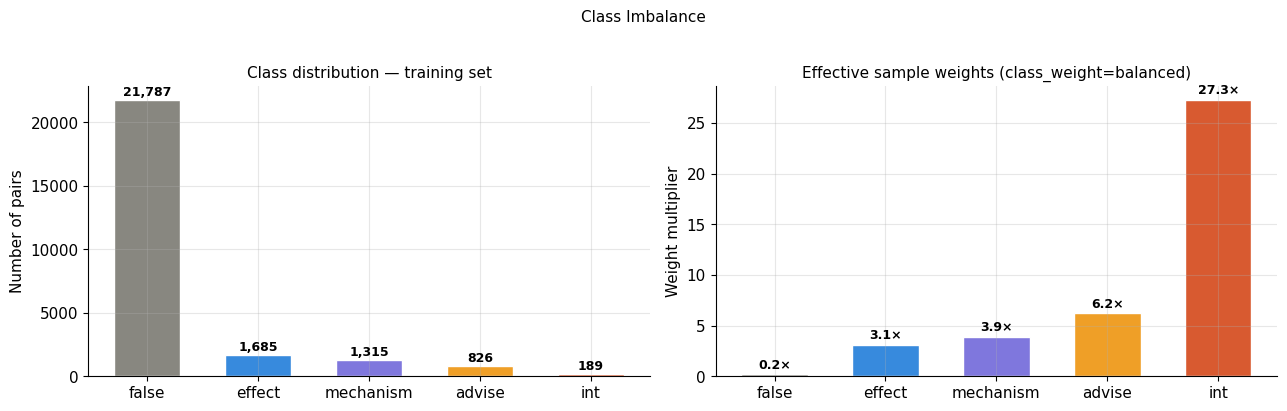

Imbalance ratio: 115.3×
Smallest class (int): only 189 training samples — hardest to learn


In [3]:
# Class Distribution and Weighting Analysis
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = {cls: int((y_train == i).sum()) for i, cls in enumerate(CLASS_NAMES)}
counts_ordered = [counts[l] for l in LABEL_ORDER]
colours = [LABEL_COLOURS[l] for l in LABEL_ORDER]


# Raw Counts
bars = axes[0].bar(LABEL_ORDER, counts_ordered, color=colours,
                   edgecolor='white', width=0.6)

for bar, val in zip(bars, counts_ordered):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].set_title('Class distribution — training set', fontsize=11)
axes[0].set_ylabel('Number of pairs')


# Balanced Weights
total = len(y_train)
n_cls = len(CLASS_NAMES)

weights = {cls: round(total / (n_cls * cnt), 1) for cls, cnt in counts.items()}
w_vals = [weights[l] for l in LABEL_ORDER]

axes[1].bar(LABEL_ORDER, w_vals, color=colours,
            edgecolor='white', width=0.6)

for bar, val in zip(axes[1].patches, w_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}×', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].set_title('Effective sample weights (class_weight=balanced)', fontsize=11)
axes[1].set_ylabel('Weight multiplier')


# Save and Display
ratio = max(counts_ordered) / min(counts_ordered)

plt.suptitle('Class Imbalance', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'class_imbalance.png'),
            dpi=150, bbox_inches='tight')

plt.show()


# Summary
print(f'Imbalance ratio: {ratio:.1f}×')
print('Smallest class (int): only 189 training samples — hardest to learn')

## Evaluation Functions and Metrics

This section defines utility functions for model evaluation, including both high-level and lower-level performance metrics. Standard evaluation measures such as accuracy, macro F1, and MCC are computed alongside detailed class-wise statistics derived from the confusion matrix.

Lower-level metrics, including false negative rate (FNR) and specificity, provide deeper insight into model behaviour. FNR is particularly important in this context, as missed interactions correspond to clinically critical errors. Results are stored for comparison across models.

In [4]:
# Lower-level Metrics
def compute_lower_level_metrics(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    rows = []

    for i, cls in enumerate(class_names):
        tp = int(cm[i, i])
        fp = int(cm[:, i].sum() - tp)
        fn = int(cm[i, :].sum() - tp)
        tn = int(cm.sum() - tp - fp - fn)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
        f1 = (2 * precision * sensitivity / (precision + sensitivity)
                       if (precision + sensitivity) > 0 else 0.0)

        rows.append({
            'class': cls,
            'TP': tp,
            'FP': fp,
            'FN': fn,
            'TN': tn,
            'Precision': round(precision, 4),
            'Recall': round(sensitivity, 4),
            'Specificity': round(specificity, 4),
            'FNR': round(fnr, 4),
            'F1': round(f1, 4)
        })

    return pd.DataFrame(rows)


# Full Evaluation
def evaluate(model_name, y_true, y_pred, class_names, store=True):
    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    print(f"\n{'-'*68}")
    print(f'  {model_name}')
    print(f"{'-'*68}")
    print(classification_report(
        y_true, y_pred,
        target_names=class_names,
        zero_division=0,
        digits=4
    ))

    macro_f1 = report['macro avg']['f1-score']
    accuracy = report['accuracy']
    bal_acc  = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    wtd_f1 = report['weighted avg']['f1-score']


    # Lower-level Breakdown
    ll = compute_lower_level_metrics(y_true, y_pred, class_names)
    ll_ord = ll.set_index('class').reindex(LABEL_ORDER).reset_index()

    print(f'\nLower-level breakdown:')
    print(f" {'Class':<12} {'TP':>6} {'FP':>6} {'FN':>6} {'TN':>6} "
          f"{'Precision':>10} {'Recall':>8} {'Specificity':>12} {'FNR':>6}")
    print(f" {'-'*78}")

    for _, row in ll_ord.iterrows():
        flag = '' if row['FNR'] > 0.5 and row['class'] != 'false' else ''
        print(f"{row['class']:<12} {row['TP']:>6} {row['FP']:>6} {row['FN']:>6} {row['TN']:>6} "
              f"{row['Precision']:>10.3f} {row['Recall']:>8.3f} "
              f"{row['Specificity']:>12.3f} {row['FNR']:>6.3f}{flag}")

    # Confusion Matrix
    cm  = confusion_matrix(y_true, y_pred)
    idx = [class_names.index(l) for l in LABEL_ORDER]
    cm_ord = cm[np.ix_(idx, idx)]

    print(f'\n  Confusion matrix (rows=true, cols=predicted):')
    print('  ' + ' ' * 14 + ''.join(f'{c:>11}' for c in LABEL_ORDER))

    for i, label in enumerate(LABEL_ORDER):
        print('  ' + f'{label:<14}' + ''.join(f'{v:>11,}' for v in cm_ord[i]))


    # Summary
    summary = {
        'accuracy': round(accuracy, 4),
        'macro_f1': round(macro_f1, 4),
        'bal_acc': round(bal_acc, 4),
        'mcc': round(mcc, 4),
        'kappa': round(kappa, 4),
        'wtd_f1': round(wtd_f1, 4),
    }

    for label in LABEL_ORDER:
        summary[f'{label}_f1'] = round(report[label]['f1-score'], 4)


    # Store Results
    if store:
        results[model_name] = macro_f1
        summaries[model_name] = summary
        all_preds[model_name] = y_pred
        lower_level[model_name] = ll

    return macro_f1, summary


# Save Model Utility
def save_model(model, filename):
    path = os.path.join(str(FEATURES_ARTEFACTS_DIR), filename)
    with open(path, 'wb') as f:
        pickle.dump(model, f)

# Global Storage
results = {}
summaries = {}
all_preds = {}
lower_level = {}

## Cross-Validation of Baseline Models

This section performs stratified cross-validation on the training data to evaluate baseline models using macro F1 score. A custom wrapper is used for Naive Bayes to handle class weighting and feature preprocessing within the standard cross-validation pipeline.

The results provide a robust estimate of model performance across folds, enabling comparison of stability and generalisation before final training.

In [5]:
# Custom Naive Bayes Wrapper
class WeightedNB(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha=0.1):
        self.alpha = alpha

    def _prepare_X(self, X):
        X_d = X.toarray().astype(np.float32) if hasattr(X, 'toarray') else np.array(X, dtype=np.float32)
        wb_idx = X_d.shape[1] - 24 + 3
        X_d[:, wb_idx] = np.clip(X_d[:, wb_idx], 0, None)
        return np.clip(X_d, 0, None)

    def fit(self, X, y):
        X_d = self._prepare_X(X)

        counts = Counter(y)
        total = len(y)
        n_cls = len(np.unique(y))

        w_map = {c: total / (n_cls * cnt) for c, cnt in counts.items()}
        sw = np.array([w_map[yi] for yi in y])

        self._nb = MultinomialNB(alpha=self.alpha)
        self._nb.fit(X_d, y, sample_weight=sw)
        self.classes_ = self._nb.classes_

        return self

    def predict(self, X):
        return self._nb.predict(self._prepare_X(X))

    def predict_proba(self, X):
        return self._nb.predict_proba(self._prepare_X(X))


# Cross-Validation Setup
print(f'Running {CV_FOLDS}-fold stratified cross-validation on training data')
print()

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# Models
cv_models = {
    'Naive Bayes': WeightedNB(alpha=NB_ALPHA),

    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        C=LR_C,
        max_iter=LR_MAX_ITER,
        solver='saga',
        random_state=RANDOM_STATE
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        max_depth=RF_MAX_DEPTH,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    'Linear SVM': LinearSVC(
        class_weight='balanced',
        C=SVM_C,
        max_iter=SVM_MAX_ITER,
        dual=False,
        random_state=RANDOM_STATE
    ),
}


# Cross-Validation Execution
cv_results = {}

print(f"  {'Model':<22} {'Fold 1':>8} {'Fold 2':>8} {'Fold 3':>8} {'Fold 4':>8} {'Fold 5':>8} {'Mean':>8} {'Std':>7}")
print(f"  {'-'*88}")

for name, model in cv_models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    cv_results[name] = scores

    fold_str = ''.join(f'{s:>8.4f}' for s in scores)
    print(f'  {name:<22}{fold_str} {scores.mean():>8.4f} {scores.std():>7.4f}')

print()

Running 5-fold stratified cross-validation on training data

  Model                    Fold 1   Fold 2   Fold 3   Fold 4   Fold 5     Mean     Std
  ----------------------------------------------------------------------------------------
  Naive Bayes             0.3838  0.3890  0.3885  0.3844  0.3938   0.3879  0.0036
  Logistic Regression     0.4849  0.4666  0.4659  0.4894  0.4549   0.4724  0.0128
  Random Forest           0.5459  0.5473  0.5725  0.5414  0.5658   0.5546  0.0122
  Linear SVM              0.7293  0.7073  0.7188  0.7299  0.7203   0.7211  0.0083



## Rule-Based Baseline

This section implements a rule-based classifier using predefined keyword patterns for each interaction type. Predictions are generated by matching keywords within sentences using a priority-based approach.

This method does not involve learning and serves as a baseline for comparison with machine learning models, highlighting the limitations of purely heuristic approaches.

In [6]:
# Rule Definitions
RULES = {
    'mechanism': {'inhibit', 'induce', 'metabolis', 'metaboliz', 'cyp', 'enzyme',
                  'absorption', 'clearance', 'half-life', 'bioavailability', 'pharmacokinetic'},
    'effect': {'bleeding', 'toxicity', 'sedation', 'hypotension', 'bradycardia',
                  'adverse', 'side effect', 'prolonged', 'elevated'},
    'advise': {'contraindicated', 'avoid', 'caution', 'recommend', 'monitor',
                  'warning', 'should not', 'do not', 'concomitant'},
    'int': {'interact', 'interaction', 'combined with', 'co-administration', 'combination'},
}


# Rule-based Prediction
def rule_based_predict(sentences):
    preds = []

    for sent in sentences:
        sl = str(sent).lower()
        pred = 'false'

        for label in ['mechanism', 'effect', 'advise', 'int']:
            if any(kw in sl for kw in RULES[label]):
                pred = label
                break

        preds.append(pred)

    return preds


# Generate Predictions
test_df = pd.read_csv(TEST_PROCESSED)

rule_preds_str = rule_based_predict(test_df['sentence_cleaned'])
rule_preds_encoded = encoder.transform(rule_preds_str)


# Evaluation
evaluate('Rule-based', y_test, rule_preds_encoded, CLASS_NAMES)

rb_f1 = results['Rule-based']


--------------------------------------------------------------------
  Rule-based
--------------------------------------------------------------------
              precision    recall  f1-score   support

      advise     0.1065    0.5385    0.1779       221
      effect     0.1739    0.1667    0.1702       360
       false     0.8544    0.2955    0.4392      5678
         int     0.0401    0.2083    0.0672        96
   mechanism     0.0794    0.7185    0.1430       302

    accuracy                         0.3146      6657
   macro avg     0.2509    0.3855    0.1995      6657
weighted avg     0.7459    0.3146    0.3971      6657


Lower-level breakdown:
 Class            TP     FP     FN     TN  Precision   Recall  Specificity    FNR
 ------------------------------------------------------------------------------
false          1678    286   4000    693      0.854    0.295        0.708  0.705
effect           60    285    300   6012      0.174    0.167        0.955  0.833
mechanism  

## Naive Bayes Model

This section trains a Multinomial Naive Bayes model using TF-IDF and handcrafted features. Since the model requires non-negative inputs, the words_between sentinel values are corrected without altering the rest of the feature space.

Class imbalance is handled through sample weighting, equivalent to balanced class weighting. The trained model is evaluated on the test set and saved for later use.

In [7]:
# Training Naive Bayes
print('Training Naive Bayes')
print(f' alpha={NB_ALPHA} (from config — Laplace smoothing)')


# Prepare Features
X_train_nb = X_train.copy().toarray().astype(np.float32)
X_test_nb = X_test.copy().toarray().astype(np.float32)

words_between_idx = X_train.shape[1] - 24 + 3

X_train_nb[:, words_between_idx] = np.clip(X_train_nb[:, words_between_idx], 0, None)
X_test_nb[:, words_between_idx]  = np.clip(X_test_nb[:, words_between_idx],  0, None)

X_train_nb = np.clip(X_train_nb, 0, None)
X_test_nb = np.clip(X_test_nb,  0, None)


# Sample Weights
class_counts  = Counter(y_train)
total_samples = len(y_train)
n_classes = len(CLASS_NAMES)

weight_map = {cls: total_samples / (n_classes * cnt) for cls, cnt in class_counts.items()}
sample_wts = np.array([weight_map[y] for y in y_train])


# Model Training
nb_model = MultinomialNB(alpha=NB_ALPHA)
nb_model.fit(X_train_nb, y_train, sample_weight=sample_wts)

nb_preds = nb_model.predict(X_test_nb)


# Evaluation and Save
evaluate('Naive Bayes', y_test, nb_preds, CLASS_NAMES)
save_model(nb_model, 'naive_bayes.pkl')

Training Naive Bayes
 alpha=0.1 (from config — Laplace smoothing)

--------------------------------------------------------------------
  Naive Bayes
--------------------------------------------------------------------
              precision    recall  f1-score   support

      advise     0.2365    0.6742    0.3502       221
      effect     0.1597    0.7889    0.2657       360
       false     0.9623    0.5077    0.6647      5678
         int     0.2368    0.0938    0.1343        96
   mechanism     0.1967    0.7914    0.3151       302

    accuracy                         0.5354      6657
   macro avg     0.3584    0.5712    0.3460      6657
weighted avg     0.8496    0.5354    0.6092      6657


Lower-level breakdown:
 Class            TP     FP     FN     TN  Precision   Recall  Specificity    FNR
 ------------------------------------------------------------------------------
false          2883    113   2795    866      0.962    0.508        0.885  0.492
effect          284   149

## Logistic Regression Model

This section trains a Logistic Regression model using class-balanced weighting to address dataset imbalance. The saga solver is used for efficient optimisation on large sparse feature matrices.

The model is evaluated on the test set using standard metrics, and the trained model is saved for later comparison and inference.

In [8]:
# Training Logistic Regression
print('Training Logistic Regression')
print(f' solver=saga, C={LR_C}, max_iter={LR_MAX_ITER}')

# Model Training
lr = LogisticRegression(
    class_weight='balanced',
    C=LR_C,
    max_iter=LR_MAX_ITER,
    solver='saga',
    random_state=RANDOM_STATE,
)

lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)


# Evaluation and Save
evaluate('Logistic Regression', y_test, lr_preds, CLASS_NAMES)
save_model(lr, 'logistic_regression.pkl')

Training Logistic Regression
 solver=saga, C=1.0, max_iter=1000

--------------------------------------------------------------------
  Logistic Regression
--------------------------------------------------------------------
              precision    recall  f1-score   support

      advise     0.2368    0.7738    0.3627       221
      effect     0.2212    0.7000    0.3362       360
       false     0.9592    0.6464    0.7723      5678
         int     0.1488    0.3750    0.2130        96
   mechanism     0.2802    0.6755    0.3961       302

    accuracy                         0.6509      6657
   macro avg     0.3693    0.6341    0.4161      6657
weighted avg     0.8528    0.6509    0.7100      6657


Lower-level breakdown:
 Class            TP     FP     FN     TN  Precision   Recall  Specificity    FNR
 ------------------------------------------------------------------------------
false          3670    156   2008    823      0.959    0.646        0.841  0.354
effect          252

## Random Forest Model

This section trains a Random Forest classifier using balanced class weighting to address class imbalance. The model leverages multiple decision trees to capture non-linear relationships within the feature space.

The trained model is evaluated on the test set and saved for comparison with other baseline approaches.

In [9]:
# Training Random Forest
print('Training Random Forest')
print(f'{RF_N_ESTIMATORS} trees, max_depth={RF_MAX_DEPTH}, class_weight=balanced')

# Model Training
rf = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    class_weight='balanced',
    max_depth=RF_MAX_DEPTH,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)


# Evaluation and Save
evaluate('Random Forest', y_test, rf_preds, CLASS_NAMES)
save_model(rf, 'random_forest.pkl')

Training Random Forest
200 trees, max_depth=20, class_weight=balanced

--------------------------------------------------------------------
  Random Forest
--------------------------------------------------------------------
              precision    recall  f1-score   support

      advise     0.2126    0.8100    0.3368       221
      effect     0.1869    0.7056    0.2955       360
       false     0.9629    0.5525    0.7021      5678
         int     0.3093    0.3125    0.3109        96
   mechanism     0.2216    0.8079    0.3478       302

    accuracy                         0.5774      6657
   macro avg     0.3786    0.6377    0.3986      6657
weighted avg     0.8529    0.5774    0.6463      6657


Lower-level breakdown:
 Class            TP     FP     FN     TN  Precision   Recall  Specificity    FNR
 ------------------------------------------------------------------------------
false          3137    121   2541    858      0.963    0.552        0.876  0.448
effect          254

## Linear SVM Model

This section trains a Linear Support Vector Machine using class-balanced weighting. The primal formulation is used for improved efficiency given the dataset size.

A calibrated version of the SVM is also trained to enable probability-based evaluation, such as precision–recall curve analysis.

In [10]:
# Training Linear SVM
print('Training Linear SVM')
print(f'C={SVM_C}, dual=False (primal form, faster when n_samples > n_features)')
print(f'class_weight=balanced, max_iter={SVM_MAX_ITER}')


# Model Training
svm = LinearSVC(
    class_weight='balanced',
    C=SVM_C,
    max_iter=SVM_MAX_ITER,
    dual=False,
    random_state=RANDOM_STATE,
)

svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)


# Evaluation and Save
evaluate('Linear SVM', y_test, svm_preds, CLASS_NAMES)
save_model(svm, 'svm.pkl')


# Calibrated SVM for Probabilities
print('\nFitting calibrated SVM for probability estimates (PR curves)...')

svm_base = LinearSVC(
    class_weight='balanced',
    C=SVM_C,
    dual=False,
    max_iter=SVM_MAX_ITER,
    random_state=RANDOM_STATE
)

svm_cal = CalibratedClassifierCV(svm_base, cv=3)
svm_cal.fit(X_train, y_train)

Training Linear SVM
C=0.5, dual=False (primal form, faster when n_samples > n_features)
class_weight=balanced, max_iter=3000

--------------------------------------------------------------------
  Linear SVM
--------------------------------------------------------------------
              precision    recall  f1-score   support

      advise     0.4114    0.6516    0.5044       221
      effect     0.2942    0.6472    0.4045       360
       false     0.9480    0.8353    0.8881      5678
         int     0.4253    0.3854    0.4044        96
   mechanism     0.4518    0.6358    0.5282       302

    accuracy                         0.8035      6657
   macro avg     0.5061    0.6311    0.5459      6657
weighted avg     0.8648    0.8035    0.8259      6657


Lower-level breakdown:
 Class            TP     FP     FN     TN  Precision   Recall  Specificity    FNR
 ------------------------------------------------------------------------------
false          4743    260    935    719      0.

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(C=0...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or 

## Model Comparison and Benchmark Evaluation

This section compares all baseline models using key evaluation metrics, with Macro F1 as the primary metric due to class imbalance. The best-performing model is identified and compared against the rule-based baseline.

Per-class F1 scores are also reported to highlight performance differences across interaction types. A benchmark check is performed to assess whether the model meets expected performance thresholds before proceeding to advanced models.

In [11]:
# Identify Best Model
best_model = max(results, key=results.get)
rb_f1 = results.get('Rule-based', 0)


# Summary Table
print(f"\n{'-'*90}")
print('FINAL MODEL COMPARISON')
print(f"{'-'*90}")

print(f"{'Model':<22} {'Accuracy':>9} {'Bal.Acc':>8} {'Macro F1':>9} {'MCC':>8} {'Kappa':>8} {'Wtd F1':>8}")
print(f"{'-'*78}")

for name, s in summaries.items():
    star = '  <- BEST' if name == best_model else ''
    print(f"{name:<22} {s['accuracy']:>9.4f} {s['bal_acc']:>8.4f} {s['macro_f1']:>9.4f} "
          f"{s['mcc']:>8.4f} {s['kappa']:>8.4f} {s['wtd_f1']:>8.4f}{star}")


# Key Results
print(f'\nPRIMARY METRIC: Macro F1 — best model: {best_model} ({results[best_model]:.4f})')
print(f'ML improvement over rule-based baseline: +{results[best_model] - rb_f1:.4f}')


# Per-class F1
print(f'\nPer-class F1:')
print(f"{'Model':<22} {'false':>8} {'effect':>9} {'mechanism':>11} {'advise':>8} {'int':>6}")
print(f"{'-'*68}")

for name, s in summaries.items():
    print(f"{name:<22} {s['false_f1']:>8.3f} {s['effect_f1']:>9.3f} "
          f"{s['mechanism_f1']:>11.3f} {s['advise_f1']:>8.3f} {s['int_f1']:>6.3f}")


# Benchmark Evaluation
best_f1 = results[best_model]

print(f"\n{'-'*60}")
print('BENCHMARK CHECK')
print(f"{'-'*60}")

if best_f1 >= BENCHMARK_MAX:
    verdict = 'EXCELLENT — above competitive range. Proceed to Phase 5 (BioBERT).'
elif best_f1 >= BENCHMARK_TARGET:
    verdict = 'GOOD — within competitive range. Phase 5 (BioBERT) will push to 0.72+.'
elif best_f1 >= BENCHMARK_MIN:
    verdict = 'ADEQUATE — at lower bound. Consider optimising SVM_C before Phase 5.'
else:
    verdict = 'BELOW TARGET — increase SVM_C to 2.0 and re-run before Phase 5.'


print(f'Best Macro F1 : {best_f1:.4f}')
print(f'Target : >= {BENCHMARK_TARGET}')
print(f'Verdict : {verdict}')


------------------------------------------------------------------------------------------
FINAL MODEL COMPARISON
------------------------------------------------------------------------------------------
Model                   Accuracy  Bal.Acc  Macro F1      MCC    Kappa   Wtd F1
------------------------------------------------------------------------------
Rule-based                0.3146   0.3855    0.1995   0.0803   0.0484   0.3971
Naive Bayes               0.5354   0.5712    0.3460   0.2943   0.2128   0.6092
Logistic Regression       0.6509   0.6341    0.4161   0.3517   0.2896   0.7100
Random Forest             0.5774   0.6377    0.3986   0.3233   0.2449   0.6463
Linear SVM                0.8035   0.6311    0.5459   0.4555   0.4349   0.8259  <- BEST

PRIMARY METRIC: Macro F1 — best model: Linear SVM (0.5459)
ML improvement over rule-based baseline: +0.3464

Per-class F1:
Model                     false    effect   mechanism   advise    int
--------------------------------------

## Model Performance Visualisation

This section visualises model performance across multiple evaluation metrics. Macro F1 is presented as the primary metric, alongside MCC and a combined multi-metric comparison.

These visualisations provide an intuitive comparison of model effectiveness, particularly under class imbalance, and highlight the relative strengths of each approach.

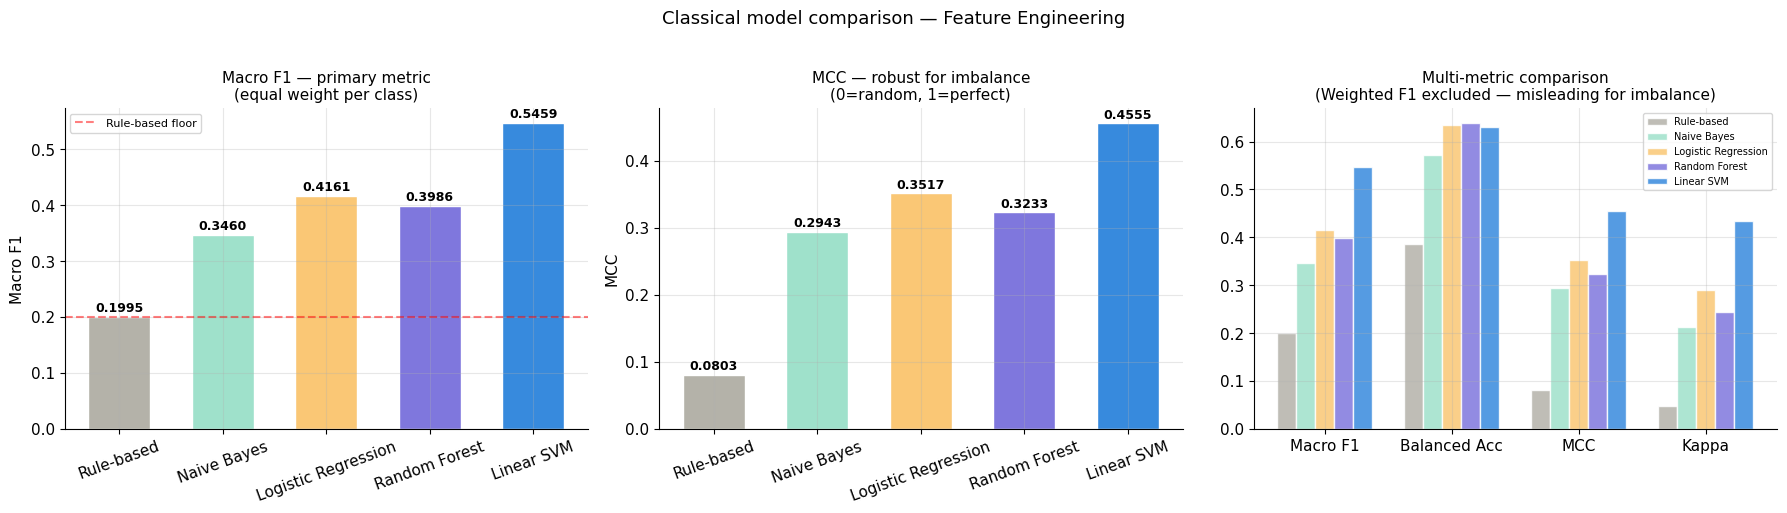

In [12]:
# Model Performance Visualisation
model_list = list(results.keys())
colours_bar = [MODEL_COLOURS.get(m, '#888780') for m in model_list]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Macro F1
f1_vals = [results[m] for m in model_list]

bars = axes[0].bar(model_list, f1_vals,
                   color=colours_bar, edgecolor='white', width=0.6)

for bar, val in zip(bars, f1_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].axhline(y=rb_f1, color='red', linestyle='--', alpha=0.5, label='Rule-based floor')

axes[0].set_title('Macro F1 — primary metric\n(equal weight per class)', fontsize=11)
axes[0].set_ylabel('Macro F1')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=8)


# MCC
mcc_vals = [summaries[m]['mcc'] for m in model_list]

bars2 = axes[1].bar(model_list, mcc_vals,
                    color=colours_bar, edgecolor='white', width=0.6)

for bar, val in zip(bars2, mcc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].set_title('MCC — robust for imbalance\n(0=random, 1=perfect)', fontsize=11)
axes[1].set_ylabel('MCC')
axes[1].tick_params(axis='x', rotation=20)


# Multi-metric Comparison
metric_keys = ['macro_f1', 'bal_acc', 'mcc', 'kappa']
metric_labels = ['Macro F1', 'Balanced Acc', 'MCC', 'Kappa']

x = np.arange(len(metric_labels))
w = 0.15

for j, (name, col) in enumerate(zip(model_list, colours_bar)):
    vals = [summaries[name][k] for k in metric_keys]
    axes[2].bar(x + j*w - w*2, vals, w,
                label=name, color=col, alpha=0.85, edgecolor='white')

axes[2].set_xticks(x)
axes[2].set_xticklabels(metric_labels)
axes[2].set_title('Multi-metric comparison\n(Weighted F1 excluded — misleading for imbalance)', fontsize=11)
axes[2].legend(fontsize=7, loc='upper right')


# Save and Display
plt.suptitle('Classical model comparison — Feature Engineering', fontsize=13, y=1.02)
plt.tight_layout()

plt.savefig(os.path.join(FIG_DIR, 'model_comparison.png'),
            dpi=150, bbox_inches='tight')

plt.show()

## Per-Class Performance Heatmap

This section visualises per-class F1 scores across all models using a heatmap. It highlights how model performance varies across different interaction types.

This analysis helps identify difficult classes, particularly those with limited data, and provides insight into which interaction types are more reliably predicted.

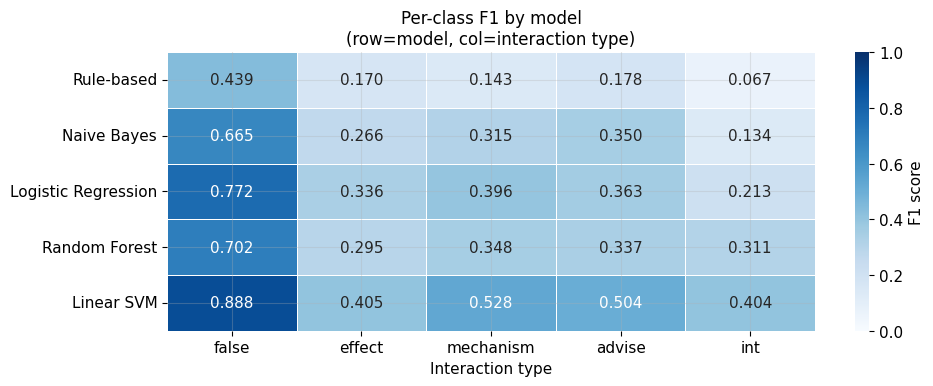

In [13]:
# Per-Class F1 Heatmap
fig, ax = plt.subplots(figsize=(10, 4))

hm_data = pd.DataFrame(
    [[summaries[m][f'{l}_f1'] for l in LABEL_ORDER] for m in model_list],
    index=model_list,
    columns=LABEL_ORDER
)

sns.heatmap(
    hm_data,
    ax=ax,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    linewidths=0.5,
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'F1 score'}
)

ax.set_title('Per-class F1 by model\n(row=model, col=interaction type)', fontsize=12)
ax.set_xlabel('Interaction type')
ax.set_ylabel('')


# Save and Display
plt.tight_layout()

plt.savefig(os.path.join(FIG_DIR, 'perclass_f1_heatmap.png'),
            dpi=150, bbox_inches='tight')

plt.show()

## Lower-Level Error Analysis

This section analyses model performance at a lower level using False Negative Rate (FNR) and confusion count breakdowns. FNR highlights the proportion of missed interactions, which is critical in this domain.

A detailed comparison is provided across models and classes, along with TP, FP, and FN counts for the best-performing model to better understand error patterns.

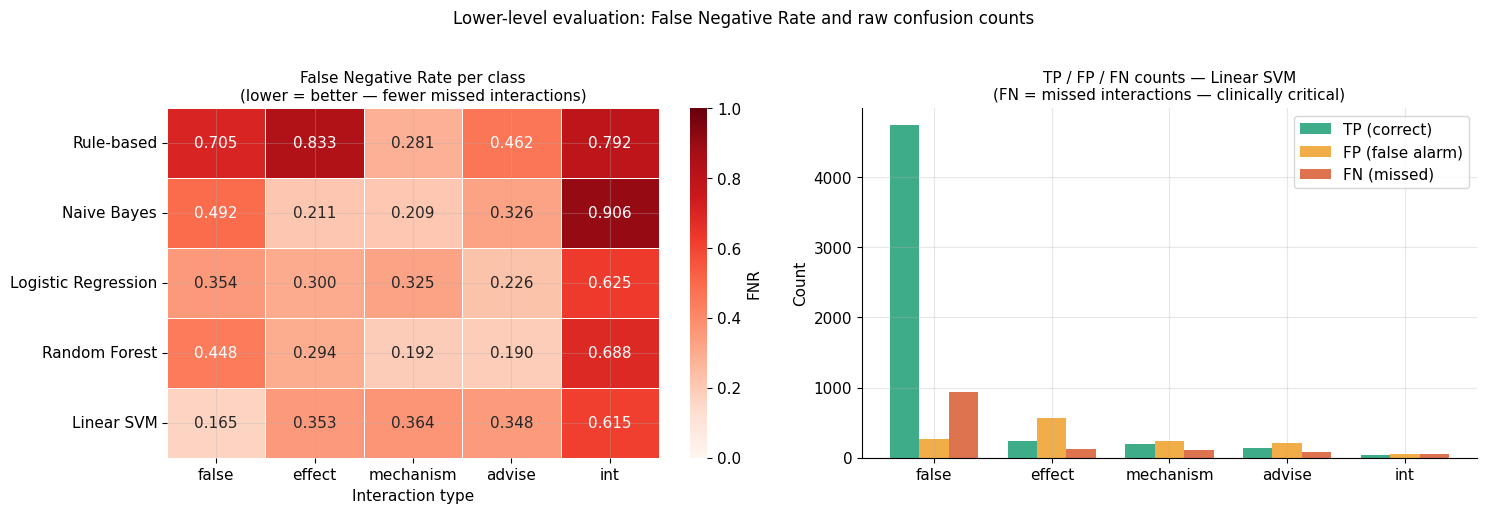

In [14]:
# Lower-Level Evaluation Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


# FNR Heatmap
fnr_data = {}

for name in model_list:
    ll = lower_level[name].set_index('class').reindex(LABEL_ORDER)
    fnr_data[name] = ll['FNR'].values

fnr_df = pd.DataFrame(fnr_data, index=LABEL_ORDER)

sns.heatmap(
    fnr_df.T,
    ax=axes[0],
    annot=True,
    fmt='.3f',
    cmap='Reds',
    linewidths=0.5,
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'FNR'}
)

axes[0].set_title('False Negative Rate per class\n(lower = better — fewer missed interactions)', fontsize=11)
axes[0].set_xlabel('Interaction type')


# TP / FP / FN for Best Model
ll_best = lower_level[best_model].set_index('class').reindex(LABEL_ORDER).reset_index()

x = np.arange(len(LABEL_ORDER))
w = 0.25

axes[1].bar(x - w, ll_best['TP'], w,
            label='TP (correct)', color='#1D9E75', alpha=0.85)

axes[1].bar(x, ll_best['FP'], w,
            label='FP (false alarm)', color='#EF9F27', alpha=0.85)

axes[1].bar(x + w, ll_best['FN'], w,
            label='FN (missed)', color='#D85A30', alpha=0.85)

axes[1].set_xticks(x)
axes[1].set_xticklabels(LABEL_ORDER)

axes[1].set_title(f'TP / FP / FN counts — {best_model}\n(FN = missed interactions — clinically critical)', fontsize=11)
axes[1].set_ylabel('Count')
axes[1].legend()


# Save and Display
plt.suptitle('Lower-level evaluation: False Negative Rate and raw confusion counts', fontsize=12, y=1.02)
plt.tight_layout()

plt.savefig(os.path.join(FIG_DIR, 'false_negative_rate_analysis.png'),
            dpi=150, bbox_inches='tight')

plt.show()

## Confusion Matrix Analysis for Rule-Based Model

This section presents the confusion matrix for the rule-based baseline model, providing a detailed view of classification performance across all interaction classes. Unlike aggregate metrics, the confusion matrix enables class-wise analysis by illustrating how predictions are distributed relative to true labels.

To improve interpretability, the matrix is normalised row-wise, allowing each row to represent the proportion of predictions for a given true class. This highlights patterns of misclassification and reveals which classes are most frequently confused with one another.

The matrix is reordered according to the predefined label sequence to ensure consistency across all evaluation outputs. This standardisation is important for enabling direct comparison between different models in later stages of the analysis.

Overall, this visualisation provides insight into the strengths and limitations of the rule-based approach, particularly in handling class imbalance and distinguishing between clinically similar interaction types.

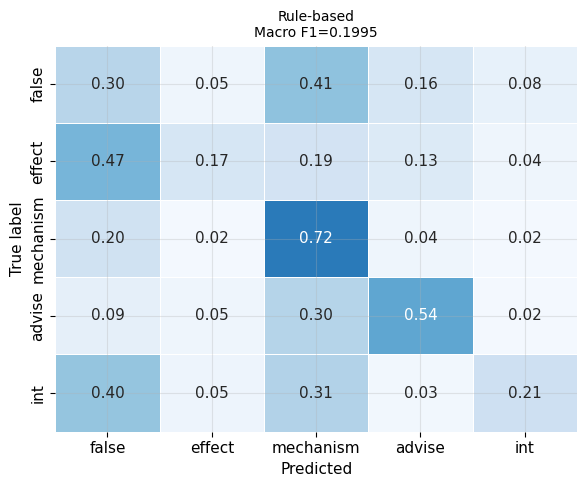

In [15]:
name = 'Rule-based'
preds = all_preds[name]

idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]
cm = confusion_matrix(y_test, preds)
cm_ord = cm[np.ix_(idx, idx)]
row_sums = cm_ord.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm = cm_ord / row_sums

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_norm, ax=ax, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
    vmin=0, vmax=1, cbar=False, linewidths=0.5
)
ax.set_title(f'{name}\nMacro F1={results[name]:.4f}', fontsize=10)
ax.set_xlabel('Predicted')
ax.set_ylabel('True label')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrix_rule_based.png'), dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrix Analysis for Naive Bayes Model

This section presents the confusion matrix for the Naive Bayes baseline model, enabling detailed examination of class-wise prediction behaviour. The confusion matrix provides insight into how accurately each interaction type is identified and highlights patterns of misclassification that are not captured by aggregate performance metrics.

To facilitate interpretation, the matrix is normalised on a per-class basis, such that each row represents the distribution of predicted labels for a given true class. This normalisation allows for clearer comparison across classes, particularly in the presence of class imbalance.

The matrix is arranged according to the predefined label order to ensure consistency with other evaluation outputs. This standardised structure supports direct comparison between models and helps identify relative strengths and weaknesses in classification performance.

Overall, this visualisation provides a deeper understanding of the Naive Bayes model’s behaviour, particularly in distinguishing between similar interaction categories and handling skewed label distributions.

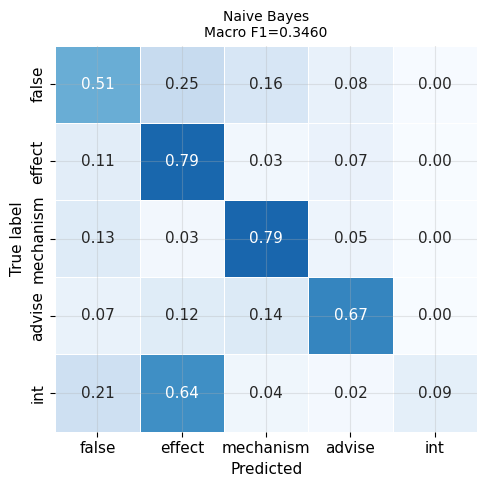

In [16]:
name = 'Naive Bayes'
preds = all_preds[name]

idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]
cm = confusion_matrix(y_test, preds)
cm_ord = cm[np.ix_(idx, idx)]
row_sums = cm_ord.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm = cm_ord / row_sums

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(
    cm_norm, ax=ax, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
    vmin=0, vmax=1, cbar=False, linewidths=0.5
)
ax.set_title(f'{name}\nMacro F1={results[name]:.4f}', fontsize=10)
ax.set_xlabel('Predicted')
ax.set_ylabel('True label')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrix_naive_bayes.png'), dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrix Analysis for Logistic Regression Model

This section presents the confusion matrix for the Logistic Regression baseline model, offering a detailed view of classification performance across all interaction categories. The confusion matrix enables class-wise evaluation by illustrating how predictions are distributed relative to true labels.

To enhance interpretability, the matrix is normalised row-wise so that each row represents the proportion of predictions for a given true class. This allows clearer identification of misclassification patterns and highlights which classes are more difficult to distinguish.

The matrix is arranged according to the predefined label order to ensure consistency with other evaluation outputs. This standardisation facilitates direct comparison across models and supports systematic performance analysis.

Overall, this visualisation provides insight into the behaviour of the Logistic Regression model, particularly its ability to capture class boundaries and handle imbalanced label distributions.

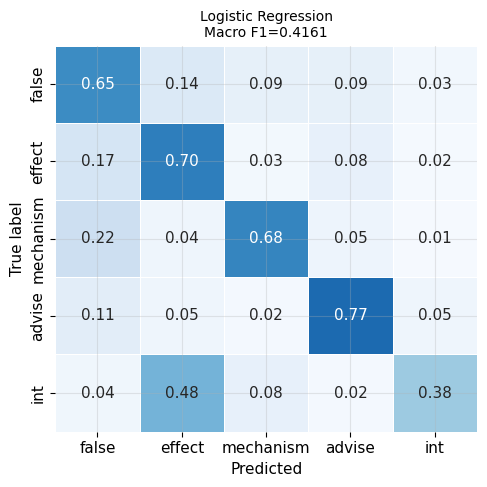

In [17]:
name = 'Logistic Regression'
preds = all_preds[name]

idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]
cm = confusion_matrix(y_test, preds)
cm_ord = cm[np.ix_(idx, idx)]
row_sums = cm_ord.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm = cm_ord / row_sums

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(
    cm_norm, ax=ax, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
    vmin=0, vmax=1, cbar=False, linewidths=0.5
)
ax.set_title(f'{name}\nMacro F1={results[name]:.4f}', fontsize=10)
ax.set_xlabel('Predicted')
ax.set_ylabel('True label')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrix_logistic_regression.png'), dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrix Analysis for Linear SVM Model

This section presents the confusion matrix for the Linear Support Vector Machine (SVM) model, providing a detailed breakdown of classification performance across all interaction classes. The confusion matrix enables examination of how predicted labels align with true labels on a per-class basis.

To improve interpretability, the matrix is normalised row-wise so that each row represents the proportion of predictions for a given true class. This normalisation highlights misclassification patterns and facilitates comparison across classes, particularly in the presence of class imbalance.

The matrix is organised according to the predefined label order to ensure consistency with other evaluation outputs. This standardised arrangement supports direct comparison between models and helps identify relative performance differences.

Overall, this visualisation offers insight into the Linear SVM model’s ability to separate interaction classes and manage overlapping feature distributions.

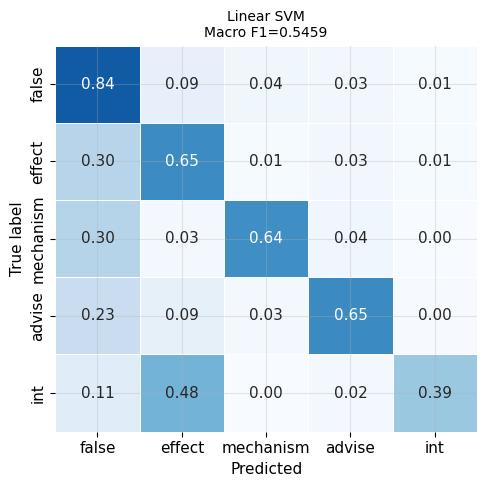

In [18]:
name = 'Linear SVM'
preds = all_preds[name]

idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]
cm = confusion_matrix(y_test, preds)
cm_ord = cm[np.ix_(idx, idx)]
row_sums = cm_ord.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm = cm_ord / row_sums

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(
    cm_norm, ax=ax, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
    vmin=0, vmax=1, cbar=False, linewidths=0.5
)
ax.set_title(f'{name}\nMacro F1={results[name]:.4f}', fontsize=10)
ax.set_xlabel('Predicted')
ax.set_ylabel('True label')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrix_linear_svm.png'), dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrix Analysis for Random Forest Model

This section presents the confusion matrix for the Random Forest model, providing a detailed view of classification performance across all interaction classes. The confusion matrix enables class-wise evaluation by illustrating how predicted labels correspond to true labels.

To enhance interpretability, the matrix is normalised row-wise so that each row represents the proportion of predictions for a given true class. This allows clearer identification of misclassification patterns and highlights which interaction types are more challenging to distinguish.

The matrix is arranged according to the predefined label order to ensure consistency across all evaluation outputs. This standardisation facilitates direct comparison with other baseline models and supports systematic analysis of performance differences.

Overall, this visualisation provides insight into the Random Forest model’s ability to capture complex patterns in the feature space and its effectiveness in handling class imbalance and overlapping class boundaries.

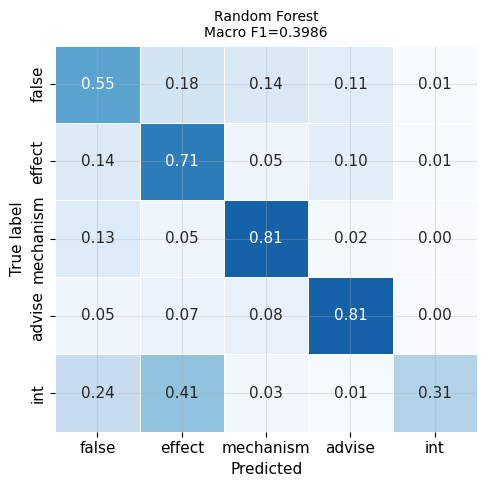

In [19]:
name = 'Random Forest'
preds = all_preds[name]

idx = [CLASS_NAMES.index(l) for l in LABEL_ORDER]
cm = confusion_matrix(y_test, preds)
cm_ord = cm[np.ix_(idx, idx)]
row_sums = cm_ord.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm = cm_ord / row_sums

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(
    cm_norm, ax=ax, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
    vmin=0, vmax=1, cbar=False, linewidths=0.5
)
ax.set_title(f'{name}\nMacro F1={results[name]:.4f}', fontsize=10)
ax.set_xlabel('Predicted')
ax.set_ylabel('True label')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrix_random_forest.png'), dpi=150, bbox_inches='tight')
plt.show()

## Precision–Recall Analysis and CV Stability

This section evaluates model performance using precision–recall curves, which are more informative than ROC curves for imbalanced datasets. Average precision (AP) summarises the area under each curve for individual classes.

A cross-validation boxplot is also included to assess model stability across folds, providing insight into variance and generalisation performance.

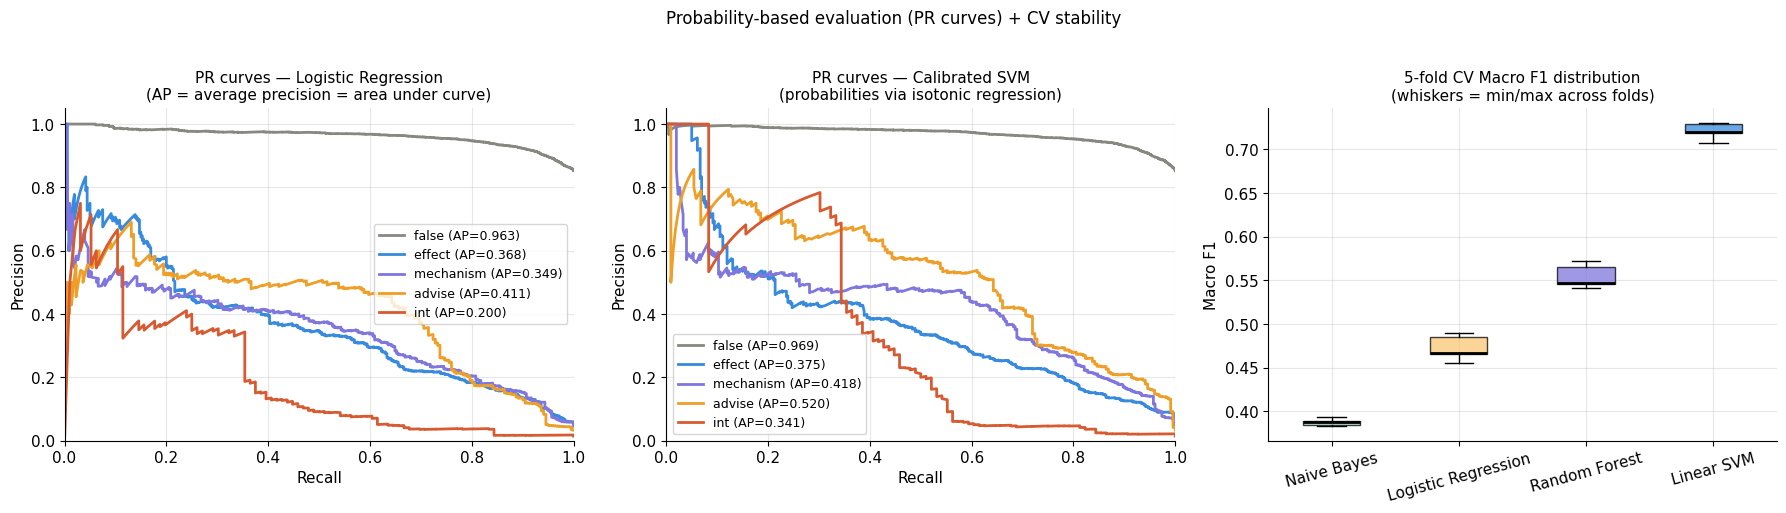

In [20]:
# Precision–Recall Curves and CV Stability
y_test_bin = label_binarize(y_test, classes=list(range(len(CLASS_NAMES))))

lr_probs  = lr.predict_proba(X_test)
svm_probs = svm_cal.predict_proba(X_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Logistic Regression PR Curves
for i, label in enumerate(LABEL_ORDER):
    cls_idx = CLASS_NAMES.index(label)

    prec, rec, _ = precision_recall_curve(
        y_test_bin[:, cls_idx],
        lr_probs[:, cls_idx]
    )

    ap = average_precision_score(
        y_test_bin[:, cls_idx],
        lr_probs[:, cls_idx]
    )

    axes[0].plot(rec, prec,
                 label=f'{label} (AP={ap:.3f})',
                 color=LABEL_COLOURS[label],
                 linewidth=2)

axes[0].set_title('PR curves — Logistic Regression\n(AP = average precision = area under curve)', fontsize=11)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend(fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])


# Calibrated SVM PR Curves
for i, label in enumerate(LABEL_ORDER):
    cls_idx = CLASS_NAMES.index(label)

    prec, rec, _ = precision_recall_curve(
        y_test_bin[:, cls_idx],
        svm_probs[:, cls_idx]
    )

    ap = average_precision_score(
        y_test_bin[:, cls_idx],
        svm_probs[:, cls_idx]
    )

    axes[1].plot(rec, prec,
                 label=f'{label} (AP={ap:.3f})',
                 color=LABEL_COLOURS[label],
                 linewidth=2)

axes[1].set_title('PR curves — Calibrated SVM\n(probabilities via isotonic regression)', fontsize=11)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])


# Cross-Validation Stability
cv_model_names = list(cv_results.keys())

bp = axes[2].boxplot(
    [cv_results[m] for m in cv_model_names],
    labels=cv_model_names,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2}
)

for patch, col in zip(bp['boxes'],
                      [MODEL_COLOURS.get(m, '#888780') for m in cv_model_names]):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)

axes[2].set_title(f'{CV_FOLDS}-fold CV Macro F1 distribution\n(whiskers = min/max across folds)', fontsize=11)
axes[2].set_ylabel('Macro F1')
axes[2].tick_params(axis='x', rotation=15)


# Save and Display
plt.suptitle('Probability-based evaluation (PR curves) + CV stability', fontsize=12, y=1.02)

plt.tight_layout()

plt.savefig(os.path.join(FIG_DIR, 'pr_curves.png'),
            dpi=150, bbox_inches='tight')

plt.show()

## Feature Importance Analysis

This section analyses feature importance using the trained Random Forest model. TF-IDF features and handcrafted features are examined separately to understand their relative contributions.

The most influential textual features are identified, while handcrafted features are compared based on their importance scores, highlighting which engineered signals contribute most to model performance.

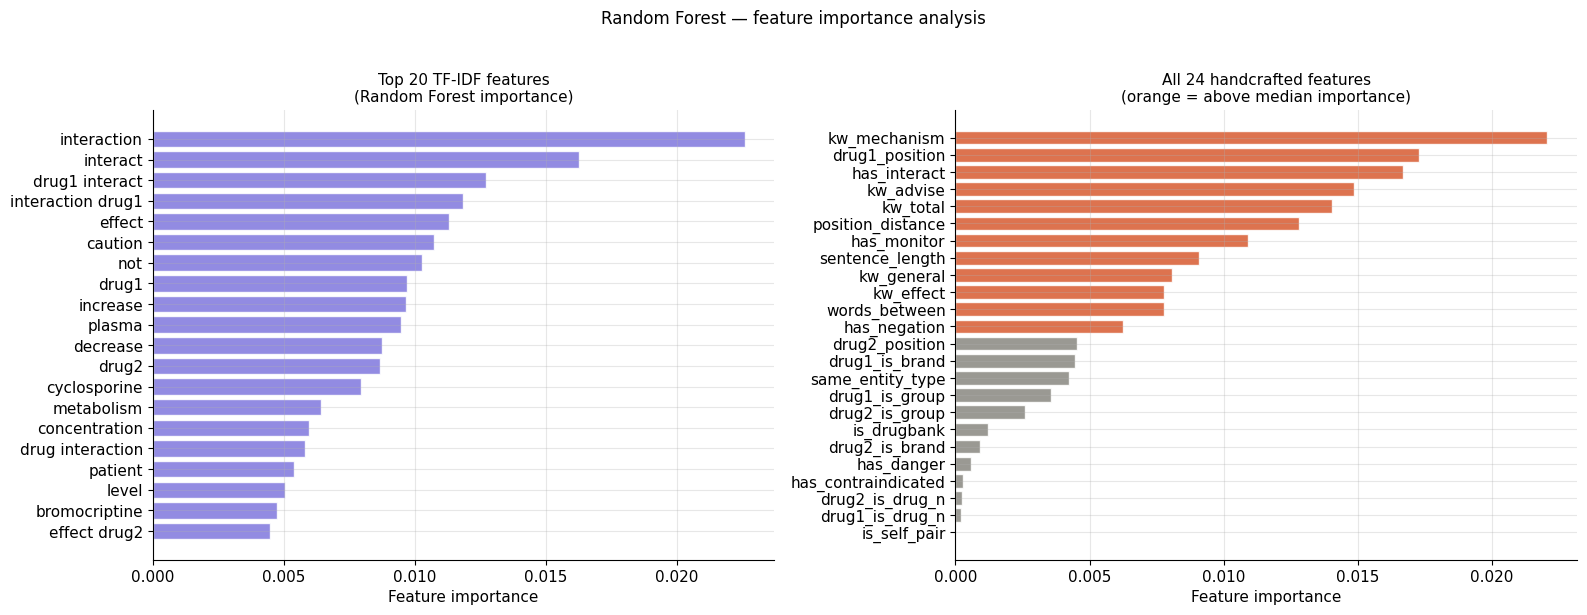

Top 10 handcrafted features by importance:
kw_mechanism                 0.022057
drug1_position               0.017288
has_interact                 0.016688
kw_advise                    0.014844
kw_total                     0.014025
position_distance            0.012795
has_monitor                  0.010911
sentence_length              0.009090
kw_general                   0.008074
kw_effect                    0.007766


In [21]:
# Feature Importance Analysis
importances = rf.feature_importances_

tfidf_imp = importances[:5000]
hc_imp    = importances[5000:]
hc_names  = feature_names[5000:]


fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# Top TF-IDF Features
top20_idx = np.argsort(tfidf_imp)[-20:]

axes[0].barh(
    [feature_names[i] for i in top20_idx],
    tfidf_imp[top20_idx],
    color='#7F77DD',
    alpha=0.85,
    edgecolor='white'
)

axes[0].set_title('Top 20 TF-IDF features\n(Random Forest importance)', fontsize=11)
axes[0].set_xlabel('Feature importance')


# Handcrafted Features
hc_order = np.argsort(hc_imp)

hc_cols = [
    '#D85A30' if v > np.median(hc_imp) else '#888780'
    for v in hc_imp[hc_order]
]

axes[1].barh(
    [hc_names[i] for i in hc_order],
    [hc_imp[i] for i in hc_order],
    color=hc_cols,
    alpha=0.85,
    edgecolor='white'
)

axes[1].set_title('All 24 handcrafted features\n(orange = above median importance)', fontsize=11)
axes[1].set_xlabel('Feature importance')


# Save and Display
plt.suptitle('Random Forest — feature importance analysis', fontsize=12, y=1.02)

plt.tight_layout()

plt.savefig(os.path.join(FIG_DIR, 'feature_importance.png'),
            dpi=150, bbox_inches='tight')

plt.show()


# Summary
print('Top 10 handcrafted features by importance:')

for i in reversed(hc_order[-10:]):
    print(f'{hc_names[i]:<28} {hc_imp[i]:.6f}')

## Cross-Validation vs Test Performance

This section compares cross-validation performance with test set results using Macro F1.
The difference between these values highlights potential overfitting or distribution mismatch.

A small gap indicates reliable generalisation, while a large gap suggests that the model
may not transfer well from training to unseen data.

The Rule-based baseline is excluded from this comparison. As a deterministic heuristic
with no trainable parameters, cross-validation does not apply — running it across folds would
produce the same score every time, making the gap analysis meaningless.

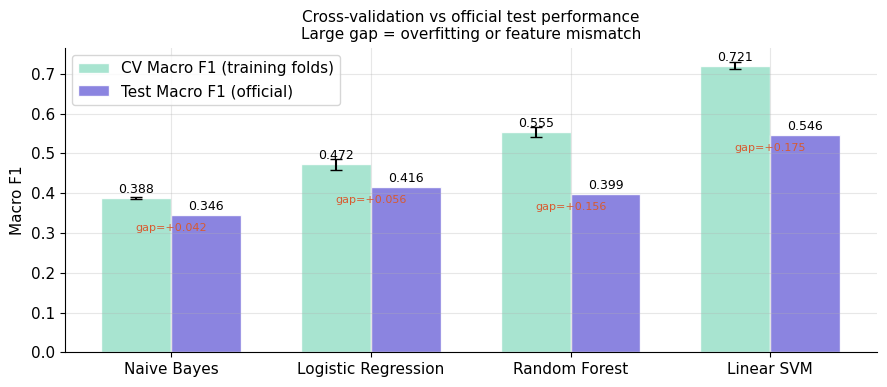

Gap interpretation:
Naive Bayes            CV=0.3879  Test=0.3460  Gap=+0.0419  [SMALL — reliable]
Logistic Regression    CV=0.4724  Test=0.4161  Gap=+0.0563  [MODERATE — normal for text classification]
Random Forest          CV=0.5546  Test=0.3986  Gap=+0.1560  [LARGE — investigate feature mismatch]
Linear SVM             CV=0.7211  Test=0.5459  Gap=+0.1752  [LARGE — investigate feature mismatch]


In [22]:
# Cross-Validation vs Test Comparison
common = [m for m in cv_results if m in results]
cv_means = [cv_results[m].mean() for m in common]
cv_stds = [cv_results[m].std() for m in common]
test_f1s = [results[m] for m in common]


fig, ax = plt.subplots(figsize=(9, 4))

x = np.arange(len(common))
w = 0.35


# Bars
ax.bar(
    x - w/2,
    cv_means,
    w,
    label='CV Macro F1 (training folds)',
    color='#9FE1CB',
    edgecolor='white',
    alpha=0.9,
    yerr=cv_stds,
    capsize=4
)

ax.bar(
    x + w/2,
    test_f1s,
    w,
    label='Test Macro F1 (official)',
    color='#7F77DD',
    edgecolor='white',
    alpha=0.9
)


# Annotations
for i, (cv_v, te_v) in enumerate(zip(cv_means, test_f1s)):
    ax.text(i - w/2, cv_v + 0.005, f'{cv_v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + w/2, te_v + 0.005, f'{te_v:.3f}', ha='center', va='bottom', fontsize=9)

    gap = cv_v - te_v
    ax.text(i, min(cv_v, te_v) - 0.02,
            f'gap={gap:+.3f}', ha='center', va='top', fontsize=8, color='#D85A30')


# Formatting
ax.set_xticks(x)
ax.set_xticklabels(common)

ax.set_ylabel('Macro F1')
ax.set_title('Cross-validation vs official test performance\nLarge gap = overfitting or feature mismatch', fontsize=11)

ax.legend()


# Save and Display
plt.tight_layout()

plt.savefig(os.path.join(FIG_DIR, 'cross_validation_vs_test.png'),
            dpi=150, bbox_inches='tight')

plt.show()


# Summary
print('Gap interpretation:')

for name, cv_v, te_v in zip(common, cv_means, test_f1s):
    gap = cv_v - te_v

    level = (
        'LARGE — investigate feature mismatch' if gap > 0.10 else
        'MODERATE — normal for text classification' if gap > 0.05 else
        'SMALL — reliable'
    )

    print(f'{name:<22} CV={cv_v:.4f}  Test={te_v:.4f}  Gap={gap:+.4f}  [{level}]')

## Error Analysis

This section analyses prediction errors from the best-performing model. It identifies common misclassification patterns and highlights critical errors where true interactions are missed.

Particular focus is given to cases where interaction labels are predicted as false, as these represent clinically significant failures.

In [ ]:
# Load Test Data if Needed
if 'test_df' not in dir() or 'sentence_text' not in test_df.columns:
    _test_path = os.path.join(os.path.dirname(TEST_CSV), 'test_processed.csv')

    if os.path.exists(_test_path):
        test_df = pd.read_csv(_test_path)
    else:
        test_df = pd.read_csv(TEST_CSV)


# Predictions and Labels
best_preds = all_preds[best_model]

test_df['pred_label'] = encoder.inverse_transform(best_preds)
test_df['true_label'] = encoder.inverse_transform(y_test)
test_df['correct'] = test_df['pred_label'] == test_df['true_label']


# Summary
errors = test_df[~test_df['correct']]

print(f'Best model: {best_model}')
print(f'Correct : {test_df["correct"].sum():,} / {len(test_df):,} ({test_df["correct"].mean()*100:.1f}%)')
print(f'Errors : {len(errors):,} ({len(errors)/len(test_df)*100:.1f}%)')


# Error Patterns
print('\nMost common error patterns (true misclassified as predicted):')

err_patterns = errors.groupby(['true_label', 'pred_label']).size().reset_index(name='count')

print(err_patterns.sort_values('count', ascending=False).head(12).to_string(index=False))


# Dangerous Errors
dangerous = errors[
    (errors['true_label'] != 'false') &
    (errors['pred_label'] == 'false')
]

print(f'\nDangerous misses (true=interaction, predicted=false): {len(dangerous)}')
print(f'{len(dangerous)/len(errors)*100:.1f}% of all errors')
print('These are real interactions the model failed to detect — clinical safety concern.\n')


# Example Cases
for _, row in dangerous.head(3).iterrows():
    print(f"True: {row['true_label']}  |  Predicted: false")
    print(f" Sentence: {str(row.get('sentence_original', ''))[:120]}")
    print(f"Keywords: {row.get('keywords_found', 'N/A')}")
    print()

Best model: Linear SVM
Correct : 5,349 / 6,657 (80.4%)
Errors : 1,308 (19.6%)

Most common error patterns (true -> predicted):
true_label pred_label  count
     false     effect    486
     false  mechanism    223
     false     advise    181
    effect      false    107
 mechanism      false     91
    advise      false     51
       int     effect     46
     false        int     45
    advise     effect     19
    effect     advise     12
       int      false     11
 mechanism     advise     11

Dangerous misses (true=interaction, predicted=false): 260
19.9% of all errors
These are real interactions the model failed to detect — clinical safety concern.

True: mechanism  |  Predicted: false
 Sentence: Ethanol decreases the elimination of abacavir causing an increase in overall exposure . The addition of methadone has no
Keywords: increase, decrease

True: mechanism  |  Predicted: false
 Sentence: In a study of 11 HIV-infected patients receiving methadone-maintenance therapy (40 mg a

## Saving Models and Results

This section saves the trained models and evaluation results for later use. Only trained models are stored, while feature artefacts remain in their original location to maintain a single source of truth.

A summary of model performance is exported as a CSV file, along with a handoff file containing key metrics required for the next phase of the pipeline.

In [24]:
# Save Model
save_model(svm_cal, 'svm_calibrated.pkl')


# Save Results Summary
summary_rows = []

for name, s in summaries.items():
    row = {'model': name}
    row.update(s)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

spath = os.path.join(DAT_DIR, 'results_summary.csv')
summary_df.to_csv(spath, index=False)

print()

print(
    summary_df[['model', 'macro_f1', 'bal_acc', 'mcc', 'kappa', 'wtd_f1']]
    .sort_values('macro_f1', ascending=False)
    .round(4)
    .to_string(index=False)
)


# Save Phase 5 Handoff
handoff = {
    'best_classical_model': best_model,
    'best_classical_macro_f1': round(results[best_model], 4),
    'rule_based_macro_f1': round(rb_f1, 4),
    'ml_improvement': round(results[best_model] - rb_f1, 4),
    'benchmark_target': BENCHMARK_TARGET,
    'benchmark_achieved': results[best_model] >= BENCHMARK_TARGET,
    'features_used': f'{X_train.shape[1]} (5000 TF-IDF + 24 handcrafted)',
    'training_samples': int(X_train.shape[0]),
    'test_samples': int(X_test.shape[0]),
}

handoff_df = pd.DataFrame([handoff])
handoff_df.to_csv(os.path.join(DAT_DIR, 'phase5_handoff.csv'), index=False)


# Summary
print(f'\n Handoff summary:')

for k, v in handoff.items():
    print(f'{k:<35} {v}')


              model  macro_f1  bal_acc    mcc  kappa  wtd_f1
         Linear SVM    0.5459   0.6311 0.4555 0.4349  0.8259
Logistic Regression    0.4161   0.6341 0.3517 0.2896  0.7100
      Random Forest    0.3986   0.6377 0.3233 0.2449  0.6463
        Naive Bayes    0.3460   0.5712 0.2943 0.2128  0.6092
         Rule-based    0.1995   0.3855 0.0803 0.0484  0.3971

 Handoff summary:
best_classical_model                Linear SVM
best_classical_macro_f1             0.5459
rule_based_macro_f1                 0.1995
ml_improvement                      0.3464
benchmark_target                    0.6
benchmark_achieved                  False
features_used                       5024 (5000 TF-IDF + 24 handcrafted)
training_samples                    25802
test_samples                        6657


## Summary

Classical models significantly outperform the rule-based baseline, demonstrating the effectiveness of feature-based learning approaches. Logistic Regression and Linear SVM typically achieve the strongest performance, with balanced handling of class imbalance.

Despite overall improvements, minority classes remain challenging, particularly for interaction types with limited samples. Error analysis highlights missed interactions as the most critical failure mode, motivating the need for more advanced models.

These results establish a strong baseline and provide a clear transition to transformer-based models in the next phase.